In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [2]:
df=pd.read_csv("../data/Walmart_cleaned.csv")

In [3]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Month_Name,Quarter,Week
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2,February,1,5
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2010,2,February,1,6
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2010,2,February,1,7
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2010,2,February,1,8
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3,March,1,9


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
 8   Year          6435 non-null   int64  
 9   Month         6435 non-null   int64  
 10  Month_Name    6435 non-null   object 
 11  Quarter       6435 non-null   int64  
 12  Week          6435 non-null   int64  
dtypes: float64(5), int64(6), object(2)
memory usage: 653.7+ KB


In [5]:
df["Date"]=pd.to_datetime(df["Date"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[ns]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
 8   Year          6435 non-null   int64         
 9   Month         6435 non-null   int64         
 10  Month_Name    6435 non-null   object        
 11  Quarter       6435 non-null   int64         
 12  Week          6435 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(6), object(1)
memory usage: 653.7+ KB


In [6]:
# Create weekly sales time series
weekly_sales=(
    df.groupby("Date")["Weekly_Sales"].sum().sort_index()
)

In [7]:
weekly_sales.head()

Date
2010-02-05    49750740.50
2010-02-12    48336677.63
2010-02-19    48276993.78
2010-02-26    43968571.13
2010-03-05    46871470.30
Name: Weekly_Sales, dtype: float64

In [9]:
print("Number of weeks:",len(weekly_sales))

Number of weeks: 143


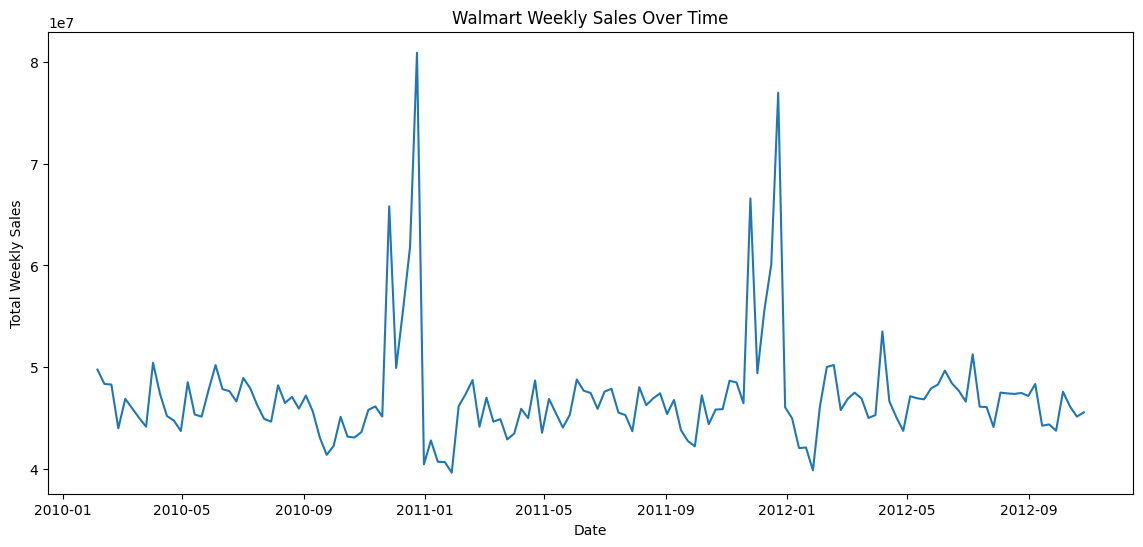

In [11]:
# Visualize the full time series
plt.figure(figsize=(14, 6))
plt.plot(
    weekly_sales.index,
    weekly_sales.values
)
plt.title("Walmart Weekly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Weekly Sales")
plt.savefig("../images/sales_forecasting/walmart_weekly_sales_over_time.png")
plt.show()

In [12]:
# Check basic statistics
weekly_sales.describe()

count    1.430000e+02
mean     4.711342e+07
std      5.444206e+06
min      3.959985e+07
25%      4.488059e+07
50%      4.624390e+07
75%      4.779202e+07
max      8.093142e+07
Name: Weekly_Sales, dtype: float64

In [13]:
print("Average weekly total sales:",weekly_sales.mean())
print("Maximum weekly total sales:",weekly_sales.max())
print("Minimum weekly total sales:",weekly_sales.min())

Average weekly total sales: 47113419.49027973
Maximum weekly total sales: 80931415.6
Minimum weekly total sales: 39599852.99


In [14]:
# Create train and test datasets
test_size=20
train=weekly_sales.iloc[:-test_size]
test=weekly_sales.iloc[-test_size:]

In [15]:
print("Training observations:", len(train))
print("Testing observations:", len(test))

Training observations: 123
Testing observations: 20


In [ ]:
print("Train starts:",train.index.min())
print("Train ends:",train.index.max())
print("Test starts:",test.index.min())
print("Test ends:",test.index.max())

Train starts: 2010-02-05 00:00:00
Train ends: 2012-06-08 00:00:00
Test starts: 2012-06-15 00:00:00
Test ends: 2012-10-26 00:00:00


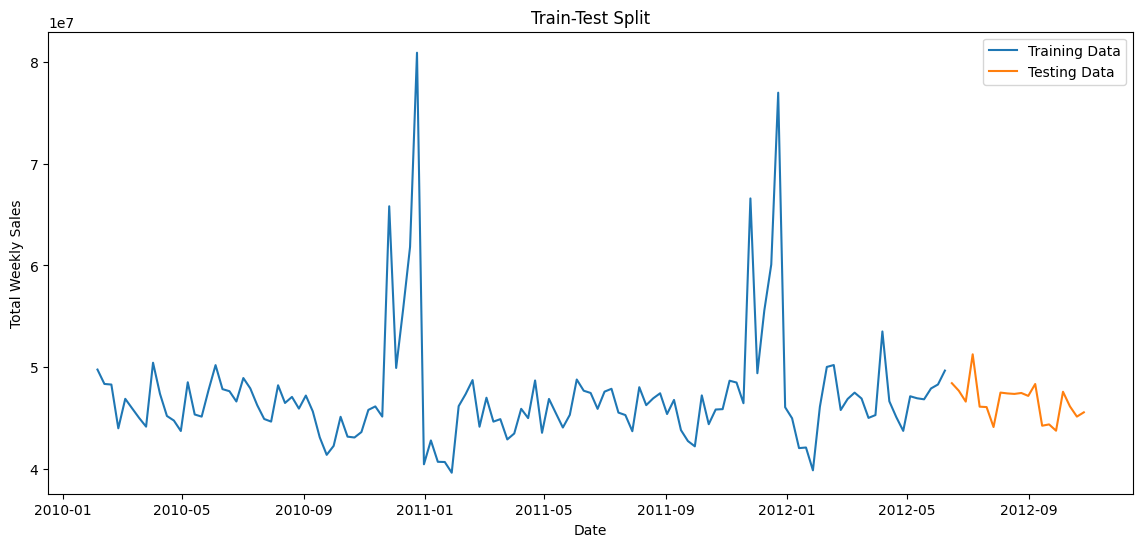

In [17]:
# Plot train and test data
plt.figure(figsize=(14, 6))
plt.plot(train.index, train.values, label="Training Data")
plt.plot(test.index, test.values, label="Testing Data")
plt.title("Train-Test Split")
plt.xlabel("Date")
plt.ylabel("Total Weekly Sales")
plt.legend()
plt.savefig("../images/sales_forecasting/train-test-split.png")
plt.show()

In [18]:
# Create a simple baseline model
baseline_value=train.mean()
baseline_predictions=np.repeat(
    baseline_value,
    len(test)
)

In [19]:
baseline_predictions[:5]

array([47196536.88089431, 47196536.88089431, 47196536.88089431,
       47196536.88089431, 47196536.88089431])

In [20]:
# Create evaluation functions
def evaluate_model(actual, predicted):
    mae=mean_absolute_error(actual, predicted)
    rmse=np.sqrt(
        mean_squared_error(actual, predicted)
    )
    mape=np.mean(
        np.abs(
            (actual-predicted)/actual
        )
    )*100
    return mae, rmse, mape

In [ ]:
# Evaluate baseline
baseline_mae, baseline_rmse, baseline_mape=evaluate_model(
    test.values,
    baseline_predictions
)
print("Baseline MAE:", baseline_mae)
print("Baseline RMSE:", baseline_rmse)
print("Baseline MAPE:", baseline_mape)

Baseline MAE: 1409530.3920894316
Baseline RMSE: 1861597.4466207067
Baseline MAPE: 3.0633337663430886


In [22]:
# Build Holt-Winters Exponential Smoothing
hw_model = ExponentialSmoothing(
    train,
    trend="add",
    seasonal="add",
    seasonal_periods=52
)

C:\Users\chakr\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


Why 52?

Because:

1 year ≈ 52 weeks

So the model checks whether sales patterns repeat annually.

In [23]:
hw_fit=hw_model.fit()

In [24]:
# Forecast the test period
hw_predictions=hw_fit.forecast(
    len(test)
)

In [25]:
hw_predictions.head()

2012-06-15    4.885810e+07
2012-06-22    4.742222e+07
2012-06-29    4.919471e+07
2012-07-06    4.929064e+07
2012-07-13    4.702344e+07
Freq: W-FRI, dtype: float64

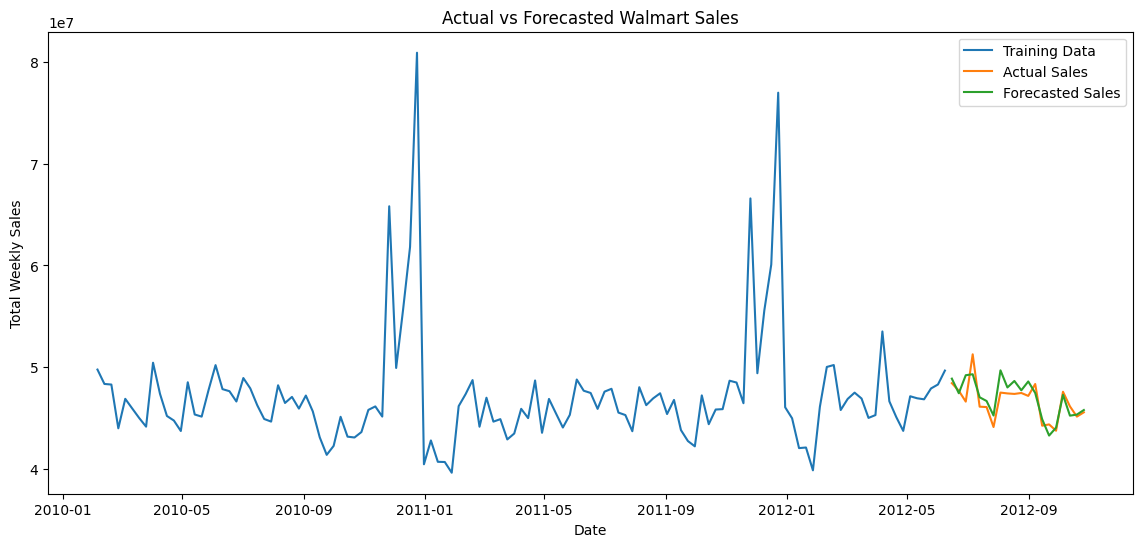

In [26]:
# Compare actual and predicted sales
plt.figure(figsize=(14, 6))
plt.plot(
    train.index,
    train.values,
    label="Training Data"
)
plt.plot(
    test.index,
    test.values,
    label="Actual Sales"
)
plt.plot(
    test.index,
    hw_predictions.values,
    label="Forecasted Sales"
)
plt.title("Actual vs Forecasted Walmart Sales")
plt.xlabel("Date")
plt.ylabel("Total Weekly Sales")
plt.legend()
plt.savefig("../images/sales_forecasting/actual_vs_forecasted_walmart_sales.png")
plt.show()

In [27]:
# Evaluate Holt-Winters
hw_mae,hw_rmse,hw_mape=evaluate_model(
    test.values,
    hw_predictions.values
)
print("Holt-Winters MAE:", hw_mae)
print("Holt-Winters RMSE:", hw_rmse)
print("Holt-Winters MAPE:", hw_mape)

Holt-Winters MAE: 910030.793610425
Holt-Winters RMSE: 1133498.41299645
Holt-Winters MAPE: 1.9401028516853207
